In [10]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols
from estimators import AIPWEstimator, HAIPWEstimator, PPIEstimator, DifferenceInMeansEstimator, PPIEstimatorCrossFit
import matplotlib.pyplot as plt

In [3]:
df_trophos = pd.read_csv("outputs/trophos_ct_loo_covariates_diff_datasets.csv")

In [4]:
aipw_estimator = AIPWEstimator()
haipw_estimator = HAIPWEstimator()
ppi_estimator = PPIEstimator()
dim_estimator = DifferenceInMeansEstimator()
ppi_estimator_crossfit = PPIEstimatorCrossFit()

## Difference in means estimator

In [5]:
Y_rct = df_trophos["LOO_RMST_SEP"]
T_rct = df_trophos["TREATMENT"]
X_rct = df_trophos[["AGE_AT_DIAGNOSIS","ONSET_SYMPTOMS", "SEX", "BMI","ALSFRS_R_TOTAL"]]

In [6]:
dm_est, dm_var = dim_estimator.estimate(X_rct, Y_rct, T_rct)
dm_var_sample = dm_var / len(Y_rct)
print(dm_est, dm_var_sample)

0.016257131093678524 0.0008803823558920516


## AIPW estimator

In [7]:
aipw = AIPWEstimator()
aipw_est, aipw_var = aipw.estimate(X_rct, Y_rct, T_rct, alpha_ridge = 1)
aipw_var_sample = aipw_var / len(Y_rct)
print(aipw_est, aipw_var_sample)

0.01862663219137964 0.0008077927221258683


## PPI estimator

In [8]:
ppi_estimator = PPIEstimator()
ppi_est, ppi_var = ppi_estimator.estimate(X_rct, Y_rct, T_rct, df_trophos['LOO_RMST_PRED_POLY_PROACT_PULSE_ANSWERALS'])
ppi_var_sample = ppi_var / len(Y_rct)
print(ppi_est, ppi_var_sample)

0.017740300587291785 0.0007920706530294061


## PPI cross-fit estimator

In [9]:
random_state = 42
B = 2000
rng = np.random.default_rng(random_state)
ppi_crossfit_estimator = PPIEstimatorCrossFit()

# Store bootstrap ATEs
boot_ates = np.zeros(B)
N = len(df_trophos)

for b in range(B):
    sample_idx = rng.integers(0, N, size=N)    # sample with replacement
    df_boot = df_trophos.iloc[sample_idx].reset_index(drop=True)

    # Built cross-val df
    df_trt = df_boot[df_boot['TREATMENT'] == 1].sample(frac=1, random_state=1).reset_index(drop=True)
    df_ctrl = df_boot[df_boot['TREATMENT'] == 0].sample(frac=1, random_state=1).reset_index(drop=True)
    half_trt = len(df_trt) // 2
    half_ctrl = len(df_ctrl) // 2
    df1 = pd.concat([df_trt.iloc[:half_trt], df_ctrl.iloc[:half_ctrl]]).sample(frac=1, random_state=1).reset_index(drop=True)
    df2 = pd.concat([df_trt.iloc[half_trt:], df_ctrl.iloc[half_ctrl:]]).sample(frac=1, random_state=1).reset_index(drop=True)

    Y_rct_1 = df1["LOO_RMST_SEP"]
    T_rct_1 = df1["TREATMENT"]
    X_rct_1 = df1[["AGE_AT_DIAGNOSIS","ONSET_SYMPTOMS", "SEX", "BMI","ALSFRS_R_TOTAL"]]
    f_model_1 = df1['LOO_RMST_PRED_POLY_PROACT_PULSE_ANSWERALS']
    Y_rct_2 = df2["LOO_RMST_SEP"]
    T_rct_2 = df2["TREATMENT"]
    X_rct_2 = df2[["AGE_AT_DIAGNOSIS","ONSET_SYMPTOMS", "SEX", "BMI","ALSFRS_R_TOTAL"]]
    f_model_2 = df2['LOO_RMST_PRED_POLY_PROACT_PULSE_ANSWERALS']


    ate_b = ppi_crossfit_estimator.estimate(
        X_rct_1, Y_rct_1, T_rct_1,
        X_rct_2, Y_rct_2, T_rct_2, 
        f_model_1, f_model_2
    )

    boot_ates[b] = ate_b

empirical_var = np.var(boot_ates, ddof=1)
ate_ppi_crossfit = np.mean(boot_ates)
lower_bound = np.percentile(boot_ates, 2.5)
upper_bound = np.percentile(boot_ates, 97.5)

results = {
    "ate_ppi_crossfit": ate_ppi_crossfit,
    "var_ate_ppi_plus_empirical": empirical_var,
    "bootstrap_ates": boot_ates,
    "ci_ate_ppi_crossfit": (lower_bound, upper_bound)
}
ppi_cross_fit_est = ate_ppi_crossfit
ppi_cross_fit_var = empirical_var

## PROCOVA estimator

In [11]:
formula = f'LOO_RMST_SEP ~ C(TREATMENT, Treatment(reference=0)) + LOO_RMST_PRED_POLY_PROACT_PULSE_ANSWERALS + AGE_AT_DIAGNOSIS + ALSFRS_R_TOTAL + SEX + ONSET_SYMPTOMS'
model = ols(formula, data=df_trophos).fit()
print(model.summary())

procova_est = model.params['C(TREATMENT, Treatment(reference=0))[T.1]']
procova_var_sample = model.bse['C(TREATMENT, Treatment(reference=0))[T.1]'] ** 2

print(procova_est, procova_var_sample)

                            OLS Regression Results                            
Dep. Variable:           LOO_RMST_SEP   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     9.910
Date:                Fri, 19 Dec 2025   Prob (F-statistic):           2.41e-10
Time:                        12:09:50   Log-Likelihood:                -134.81
No. Observations:                 508   AIC:                             283.6
Df Residuals:                     501   BIC:                             313.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

## HAIPW estimator

In [12]:
haipw = HAIPWEstimator()
Y_rct = df_trophos["LOO_RMST_SEP"]
T_rct = df_trophos["TREATMENT"]

model_predictions_y1 = [df_trophos["LOO_RMST_PRED_POLY_PROACT_PULSE_ANSWERALS"],df_trophos["LOO_RMST_PRED_COX_PROACT_PULSE_ANSWERALS"]]
model_predictions_y0 = [df_trophos["LOO_RMST_PRED_POLY_PROACT_PULSE_ANSWERALS"],df_trophos["LOO_RMST_PRED_COX_PROACT_PULSE_ANSWERALS"]]
haipw_est, haipw_var, lambdas = haipw.estimate(X_rct, Y_rct, T_rct, model_predictions_y1, model_predictions_y0)
haipw_var_sample = haipw_var / len(Y_rct)
print(haipw_est, haipw_var_sample, lambdas)

0.018020171122900733 0.0007911440320317114 [0.17087035 0.81409572 0.01503394]


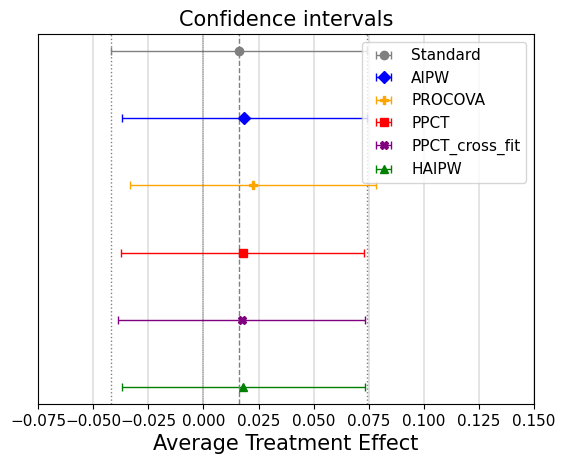

In [13]:
ate = {'Standard': dm_est, 'AIPW': aipw_est, "PROCOVA": procova_est, 'PPCT': ppi_est, 'PPCT_cross_fit': ppi_cross_fit_est, "HAIPW": haipw_est}
min_interval = {'Standard': (dm_est - 1.96 * np.sqrt(dm_var_sample)), "AIPW": (aipw_est - 1.96 * np.sqrt(aipw_var_sample)), 'PROCOVA': (procova_est - 1.96 * np.sqrt(procova_var_sample)), 'PPCT': (ppi_est - 1.96 * np.sqrt(ppi_var_sample)), 'PPCT_cross_fit': (ppi_cross_fit_est - 1.96 * np.sqrt(ppi_cross_fit_var)), "HAIPW": (haipw_est - 1.96 * np.sqrt(haipw_var_sample))}
max_interval = {'Standard': (dm_est + 1.96 * np.sqrt(dm_var_sample)), "AIPW": (aipw_est + 1.96 * np.sqrt(aipw_var_sample)), 'PROCOVA': (procova_est + 1.96 * np.sqrt(procova_var_sample)), 'PPCT': (ppi_est + 1.96 * np.sqrt(ppi_var_sample)), 'PPCT_cross_fit': (ppi_cross_fit_est + 1.96 * np.sqrt(ppi_cross_fit_var)), "HAIPW": (haipw_est + 1.96 * np.sqrt(haipw_var_sample))}


colors = {'Standard': 'grey', "AIPW": 'blue', "PROCOVA": 'orange', 'PPCT': 'red', 'PPCT_cross_fit': 'purple', "HAIPW": 'green'}
formats = {'Standard': 'o', "AIPW": 'D', 'PROCOVA': 'P', 'PPCT': 's', 'PPCT_cross_fit': 'X', "HAIPW": '^'} 
for i, method in enumerate(['Standard', "AIPW", "PROCOVA", 'PPCT', 'PPCT_cross_fit', "HAIPW"]):
    error_low = ate[method] - min_interval[method]
    error_high = max_interval[method] - ate[method]
    
    plt.errorbar(
        ate[method],             
        i * -0.1,               
        xerr=[[error_low], [error_high]],  
        fmt=formats[method],
        capsize=3,
        capthick=1,
        linestyle='None',
        elinewidth=1,
        color=colors[method],
        label=method 
    )

# Draw vertical dotted lines for Standard interval
plt.axvline(min_interval['Standard'], color='grey', linestyle=':', linewidth=1)
plt.axvline(max_interval['Standard'], color='grey', linestyle=':', linewidth=1)
plt.axvline(ate['Standard'], color='grey', linestyle='--', linewidth=1)

plt.xlabel('Average Treatment Effect', fontsize=15)
plt.title("Confidence intervals", fontsize=15)
plt.xlim([-0.075, 0.15])
# plt.ylim([-0.4, 0.12])

ax = plt.gca()
ax.yaxis.set_visible(False)
ax.tick_params(axis='x', labelsize=11)

ax.set_facecolor('white')
ax.grid(True, color='grey', linewidth=0.3)
ax.axvline(0, linestyle='--', color='black', linewidth=0.3)
ax.legend(fontsize=11)

In [14]:
df_results = pd.DataFrame({ 
    'Method': ['Standard', 'AIPW', "PROCOVA", 'PPCT', 'PPCT_cross_fit', 'HAIPW'],
    'ATE': [dm_est, aipw_est, procova_est, ppi_est, ppi_cross_fit_est, haipw_est],
    'Variance': [dm_var_sample, aipw_var_sample, procova_var_sample, ppi_var_sample, ppi_cross_fit_var, haipw_var_sample],
    '95% CI Lower': [min_interval['Standard'], min_interval['AIPW'], min_interval['PROCOVA'], min_interval['PPCT'], min_interval['PPCT_cross_fit'], min_interval['HAIPW']],
    '95% CI Upper': [max_interval['Standard'], max_interval['AIPW'], max_interval['PROCOVA'], max_interval['PPCT'], max_interval['PPCT_cross_fit'], max_interval['HAIPW']]    
})
df_results

,Method,ATE,Variance,95% CI Lower,95% CI Upper
0,Standard,0.016257,0.000880,-0.041898,0.074413
1,AIPW,0.018627,0.000808,-0.037080,0.074333
2,PROCOVA,0.022408,0.000809,-0.033338,0.078153
3,PPCT,0.017740,0.000792,-0.037421,0.072902
4,PPCT_cross_fit,0.017321,0.000815,-0.038627,0.073270
5,HAIPW,0.018020,0.000791,-0.037109,0.073150


In [120]:
print(df_results.to_latex(escape=True))

\begin{tabular}{llrrrr}
\toprule
 & Method & ATE & Variance & 95\% CI Lower & 95\% CI Upper \\
\midrule
0 & Standard & 0.016257 & 0.000880 & -0.041898 & 0.074413 \\
1 & AIPW & 0.018627 & 0.000808 & -0.037080 & 0.074333 \\
2 & PROCOVA & 0.022408 & 0.000809 & -0.033338 & 0.078153 \\
3 & PPCT & 0.017740 & 0.000792 & -0.037421 & 0.072902 \\
4 & HAIPW & 0.020498 & 0.000799 & -0.034908 & 0.075904 \\
\bottomrule
\end{tabular}

